# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used primarily for classification problems.

Unlike Linear Regression, which predicts continuous numerical values, Logistic Regression predicts the probability that an observation belongs to a particular class.

For binary classification, the target variable usually contains two classes:

* $0$: Negative class
* $1$: Positive class

For example:

* Spam / Not Spam
* Pass / Fail
* Disease / No Disease

## Why Not Use Linear Regression for Classification?

Linear Regression can produce predictions outside the range $[0,1]$.

For example:

$$
\hat{y}=-2.3
$$

or:

$$
\hat{y}=1.7
$$

These values cannot be interpreted as probabilities.

Therefore, Logistic Regression transforms the output of a linear model into a value between $0$ and $1$.

## The Logistic Model

First, we calculate a linear combination of the input features:

$$
z=w^Tx+b
$$

Then, we pass this value through the Sigmoid function.

## Sigmoid Function

The Sigmoid function is defined as:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Therefore, Logistic Regression predicts:

$$
P(y=1|x)=\sigma(w^Tx+b)
$$

The output of the Sigmoid function is always between $0$ and $1$.

### Interpretation

* If $z$ is a large negative number, $\sigma(z)$ approaches $0$.
* If $z=0$, $\sigma(z)=0.5$.
* If $z$ is a large positive number, $\sigma(z)$ approaches $1$.

The output can therefore be interpreted as the probability of belonging to class $1$.

## From Probability to Class

The model first produces a probability.

For example:

$$
P(y=1|x)=0.82
$$

A threshold is then used to convert the probability into a class.

Using the common threshold of $0.5$:

$$
P(y=1|x)\geq0.5 \Rightarrow y=1
$$

$$
P(y=1|x)<0.5 \Rightarrow y=0
$$

Thus:

| Probability | Predicted Class |
| ----------: | --------------: |
|        0.82 |               1 |
|        0.73 |               1 |
|        0.48 |               0 |
|        0.12 |               0 |

The threshold does not change the probability predicted by the model. It only determines how that probability is converted into a class label.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss_function(x , w , y):
    x = np.c_[np.ones(len (x)) , x]
    z = sigmoid(x @ w)
    return np.mean( -y * np.log(z) - (1-y) * np.log(1-z))


## Gradient of Binary Cross-Entropy Loss

For Logistic Regression, the predicted probability is:

$$
p = \sigma(z)
$$

where:

$$
z = Xw
$$

and the Sigmoid function is:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The Binary Cross-Entropy loss for $m$ training examples is:

$$
J(w)=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

### Derivative of the Loss

Using the chain rule, the derivative of the loss with respect to the model parameters simplifies to:

$$
\frac{\partial J}{\partial w}
=============================

\frac{1}{m}X^T(p-y)
$$

Therefore, the gradient of the Binary Cross-Entropy loss is:

$$
\boxed{
\nabla J(w)=\frac{1}{m}X^T(p-y)
}
$$

This result is important because it allows us to update the model parameters using Gradient Descent.

## Gradient Descent

The general Gradient Descent update rule is:

$$
w := w-\eta\nabla J(w)
$$

Substituting the Logistic Regression gradient:

$$
\boxed{
w :=
w-\eta
\frac{1}{m}X^T(p-y)
}
$$

where:

* $w$ = model parameters
* $\eta$ = learning rate
* $X$ = feature matrix
* $p$ = predicted probabilities
* $y$ = true labels
* $m$ = number of training examples

### Intuition

The vector $(p-y)$ represents the prediction error.

* If the model predicts too high, the gradient pushes the weights in the opposite direction.
* If the model predicts too low, the gradient pushes the weights in the direction that increases the prediction.
* Repeating this process gradually reduces the loss.

The complete training process can therefore be summarized as:

$$
X
\rightarrow
Xw
\rightarrow
\sigma(Xw)
\rightarrow
p-y
\rightarrow
\frac{1}{m}X^T(p-y)
\rightarrow
w-\eta\nabla J(w)
$$

This process is repeated for multiple iterations until the model converges to a suitable set of parameters.


In [3]:
def logistic_regression_GD(x, y, iteration=1000, eta=0.1):
    x = np.c_[np.ones(len(x)), x]

    w_initial = np.zeros(x.shape[1])

    for _ in range(iteration):
        gradient = (x.T @ (sigmoid(x @ w_initial) - y)) / len(y)
        w_initial -= eta * gradient

    return w_initial

def h_w(x , w) :
    x = np.c_[np.ones(len(x)), x]
    z = sigmoid(x @ w)
    return z

def h_w_plot(x , w) :
    x = np.c_[np.ones(len(x)), x]
    z = x @ w
    return z

# def decision(z) :
#     y = []
#     for i in z :
#         if(i >= 0.5) :
#             y.append(1)
#         else :
#             y.append(0)
#     return y

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
x = data.data[: , [2 , 4]]
y = data.target

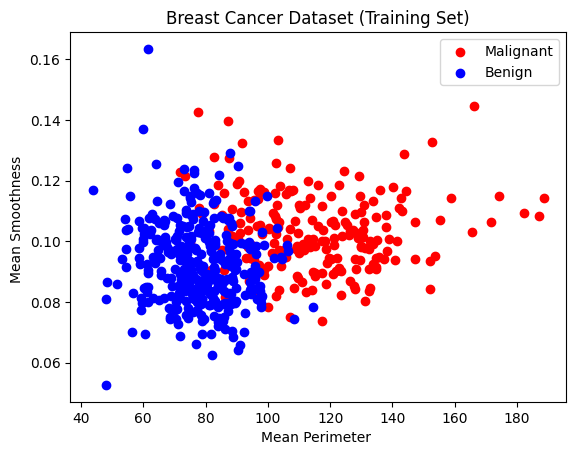

In [5]:
plt.scatter(x[y == 0, 0], x[y == 0, 1],
            color='red', label='Malignant')
plt.scatter(x[y == 1, 0], x[y == 1, 1],
            color='blue', label='Benign')
plt.xlabel('Mean Perimeter ')
plt.ylabel('Mean Smoothness ')
plt.title('Breast Cancer Dataset (Training Set)')
plt.legend()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size=0.2 , random_state=42)

In [7]:
w = logistic_regression_GD(x_train , y_train , iteration= 800)
w

C:\Users\sherv\AppData\Local\Temp\ipykernel_21252\626547369.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


array([7.4255872 , 0.25300937, 0.50978317])

In [8]:
print("Weights:", w)

y_prob = h_w(x_test, w)

print("Min probability:", y_prob.min())
print("Max probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Weights: [7.4255872  0.25300937 0.50978317]
Min probability: 0.9999999913396637
Max probability: 1.0
Mean probability: 0.9999999998886885


# The resault without Scaling is Awful
# lets try scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
w_scaled = logistic_regression_GD(
    x_train_scaled,
    y_train,
    iteration=800
)

In [11]:
y_prob_scaled = h_w(x_test_scaled, w_scaled)

y_pred_scaled = (y_prob_scaled >= 0.5).astype(int)

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix
)

print("Weights:", w_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall   :", recall_score(y_test, y_pred_scaled))
print("F1 Score :", f1_score(y_test, y_pred_scaled))
print("Log Loss :", log_loss(y_test, y_prob_scaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nProbability:")
print("Min :", y_prob_scaled.min())
print("Max :", y_prob_scaled.max())
print("Mean:", y_prob_scaled.mean())

Weights: [ 0.75107779 -3.41817701 -1.15830512]
Accuracy : 0.9385964912280702
Precision: 0.9444444444444444
Recall   : 0.9577464788732394
F1 Score : 0.951048951048951
Log Loss : 0.18830094075793444

Confusion Matrix:
[[39  4]
 [ 3 68]]

Probability:
Min : 1.2010205725383632e-05
Max : 0.9997134872828801
Mean: 0.5990384987293552


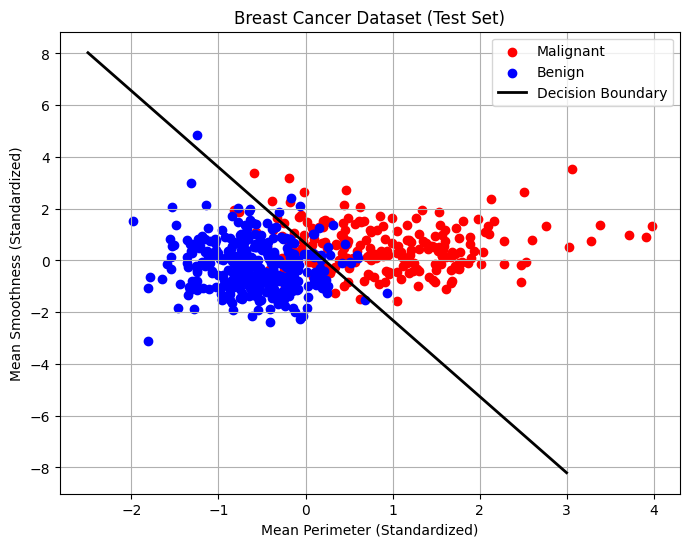

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x_test_scaled[y_test == 0, 0],
    x_test_scaled[y_test == 0, 1],
    color='red',
)
plt.scatter(
    x_train_scaled[y_train == 0, 0],
    x_train_scaled[y_train == 0, 1],
    color='red',
    label='Malignant'
)

plt.scatter(
    x_test_scaled[y_test == 1, 0],
    x_test_scaled[y_test == 1, 1],
    color='blue',
    label='Benign'
)

plt.scatter(
    x_train_scaled[y_train == 1, 0],
    x_train_scaled[y_train == 1, 1],
    color='blue',
)

# Decision Boundary
x1 = np.linspace(-2.5, 3, 300)
x2 = -(w_scaled[0] + w_scaled[1] * x1) / w_scaled[2]

plt.plot(
    x1,
    x2,
    color='black',
    linewidth=2,
    label='Decision Boundary'
)



plt.xlabel('Mean Perimeter (Standardized)')
plt.ylabel('Mean Smoothness (Standardized)')
plt.title('Breast Cancer Dataset (Test Set)')

plt.legend()
plt.grid()
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scaled , y_train)
yn = lr.predict(x_test_scaled)

print("Weights:", lr.coef_)
print("Bias:", lr.intercept_)
print("Accuracy :", accuracy_score(y_test, yn))
print("Precision:", precision_score(y_test, yn))
print("Recall   :", recall_score(y_test, yn))
print("F1 Score :", f1_score(y_test, yn))
print("Log Loss :", log_loss(y_test, yn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, yn))

Weights: [[-3.5313725  -1.17827761]]
Bias: [0.76030747]
Accuracy : 0.9385964912280702
Precision: 0.9444444444444444
Recall   : 0.9577464788732394
F1 Score : 0.951048951048951
Log Loss : 2.2132067870510532

Confusion Matrix:
[[39  4]
 [ 3 68]]


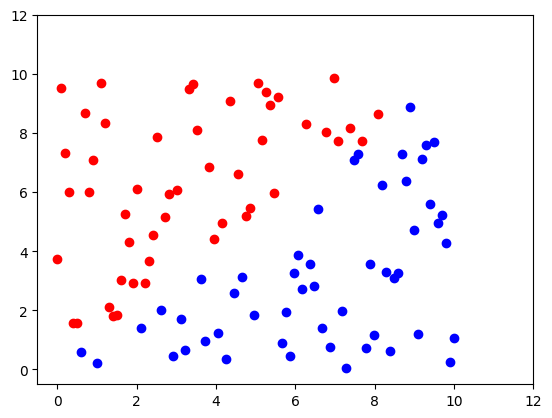

In [15]:
def generate_data() :
    np.random.seed(42)
    x = np.linspace(0 , 10 , 100)
    z = np.random.random( 100) * 10 
    y = []
    for z1 , x1 in zip(z , x) :
        if(z1 > x1) :
            y.append(1)
        else :
            y.append(0)
    x = np.c_[x , z]
    return x , y

x , y = generate_data()
y = np.array(y)
plt.scatter(x[y==1 , 0] , x[y==1 , 1] , c = "red")
plt.scatter(x[y==0 , 0] , x[y==0 , 1] , c = "blue")
plt.xlim(-0.5 , 12)
plt.ylim(-0.5 , 12)
plt.show()

In [16]:
w = logistic_regression_GD(x , y)
w

array([ 0.16532329, -2.82676493,  2.82525193])

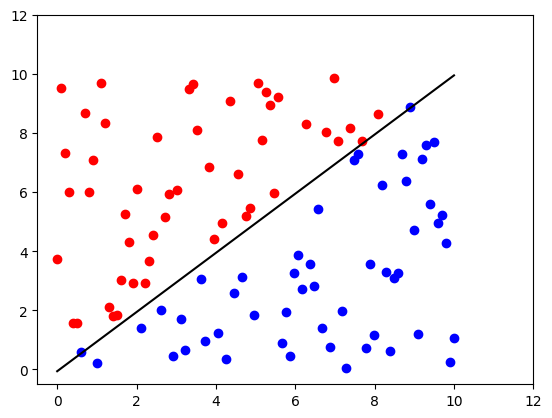

In [17]:
x_plot = np.linspace(0 , 10 , 200)
x2 = -(w[0] + w[1] * x_plot) / w[2]
plt.scatter(x[y==1 , 0] , x[y==1 , 1] , c = "red" , label = "Blue Dots")
plt.scatter(x[y==0 , 0] , x[y==0 , 1] , c = "blue" , label = "Red Dots")
plt.plot(x_plot , x2 , c = "black" , label = "Prediction")
plt.xlim(-0.5 , 12)
plt.ylim(-0.5 , 12)
plt.legend
plt.show()

# Logistic Regression — Complete Summary & Experiments

## 1. Introduction

Logistic Regression is a supervised learning algorithm mainly used for classification problems.

Unlike Linear Regression, which predicts a continuous numerical value, Logistic Regression predicts the probability that a sample belongs to a particular class.

For binary classification, the output is usually interpreted as:

* `0` → Class 0
* `1` → Class 1

The model first calculates a linear combination of the input features and then passes the result through the Sigmoid function.

---

## 2. Linear Score

The first step is calculating the linear score:

$$
z = Xw
$$

When a bias term is included:

$$
z = Xw + b
$$

The value of $z$ can be any real number.

However, we need a value between 0 and 1 to interpret the output as a probability. This is where the Sigmoid function is used.

---

## 3. Sigmoid Function

The Sigmoid function is defined as:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

It maps any real-valued input into the range:

$$
0 < \sigma(z) < 1
$$

Therefore:

$$
P(y=1|X)=\sigma(Xw)
$$

The output of the Sigmoid function can be interpreted as the probability of belonging to class 1.

For example:

* $P(y=1)=0.9$ → high probability of class 1
* $P(y=1)=0.2$ → high probability of class 0

---

## 4. Probability vs. Class Prediction

The Logistic Regression model first produces a probability, not a class directly.

For binary classification, a common threshold is 0.5:

$$
\hat{y} =
\begin{cases}
1 & p \geq 0.5 \
0 & p < 0.5
\end{cases}
$$

In Python:

```python
y_pred = (probabilities >= 0.5).astype(int)
```

Therefore, there is an important difference between:

* **Probability** → continuous value between 0 and 1
* **Predicted class** → discrete value such as 0 or 1

---

## 5. Binary Cross-Entropy / Log Loss

Mean Squared Error is not the standard loss function for Logistic Regression.

Instead, Binary Cross-Entropy (BCE), also called Log Loss, is used:

$$
J(w)=
-\frac{1}{m}
\sum_{i=1}^{m}
[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
]
$$

where:

* $y_i$ is the true label
* $p_i$ is the predicted probability
* $m$ is the number of training samples

The goal of training is to minimize this loss.

If the model gives a very confident correct prediction, the loss is small.

If the model gives a very confident wrong prediction, the loss becomes very large.

---

## 6. Gradient of the Loss

For Logistic Regression, the gradient of the Binary Cross-Entropy loss has a particularly useful form:

$$
\nabla J(w)
===========

\frac{1}{m}X^T(p-y)
$$

where:

$$
p=\sigma(Xw)
$$

Therefore, Gradient Descent updates the weights using:

$$
w := w-\eta\nabla J(w)
$$

or:

$$
w :=
w-\eta
\frac{1}{m}X^T(p-y)
$$

This gives the complete training process:

$$
X
\rightarrow
Xw
\rightarrow
\sigma(Xw)
\rightarrow
p-y
\rightarrow
\frac{1}{m}X^T(p-y)
\rightarrow
w-\eta\nabla J(w)
$$

---

## 7. Logistic Regression From Scratch

The Logistic Regression model was implemented from scratch using NumPy.

The main training function uses Gradient Descent:

```python
def logistic_regression_GD(x, y, iteration=1000, eta=0.1):
    x = np.c_[np.ones(len(x)), x]
    w_initial = np.zeros(x.shape[1])

    for _ in range(iteration):
        gradient = x.T @ (sigmoid(x @ w_initial) - y) / len(y)
        w_initial -= eta * gradient

    return w_initial
```

The implementation includes the bias term by adding a column of ones to the input matrix.

This implementation directly follows the mathematical gradient derived for Logistic Regression.

---

## 8. Testing the Model on a Synthetic Dataset

A synthetic dataset was created to understand the behavior of Logistic Regression before applying it to a real dataset.

The dataset was generated using two features, $x$ and $z$, and the class was determined according to:

$$
y =
\begin{cases}
1 & z>x \
0 & z\leq x
\end{cases}
$$

This allowed the model to learn a simple decision boundary between the two classes.

The experiment was useful for verifying that the Logistic Regression implementation was working correctly before moving to a real-world dataset.

---

## 9. Breast Cancer Dataset

The model was then tested on the Breast Cancer dataset available through Scikit-learn.

Two features were selected:

* Mean Perimeter
* Mean Smoothness

The dataset was divided into training and testing sets using `train_test_split`.

The model was trained only on the training data and evaluated on the unseen test data.

---

## 10. Feature Scaling

Feature Scaling was also tested using `StandardScaler`.

Standardization transforms a feature according to:

$$
x'=\frac{x-\mu}{\sigma}
$$

where:

* $\mu$ is the mean of the feature
* $\sigma$ is its standard deviation

The scaler was fitted only on the training data:

```python
scaler.fit_transform(x_train)
```

and then the learned transformation was applied to the test data:

```python
scaler.transform(x_test)
```

The test set must not be fitted separately because this would allow information from the test set to influence the preprocessing process and cause data leakage.

Scaling was particularly important for the custom Gradient Descent implementation because features with very different scales can make optimization slower or unstable.

---

## 11. Model Evaluation

The Logistic Regression model was evaluated using several classification metrics:

### Accuracy

$$
Accuracy =
\frac{TP+TN}{TP+TN+FP+FN}
$$

Accuracy measures the proportion of all predictions that are correct.

### Precision

$$
Precision =
\frac{TP}{TP+FP}
$$

Precision measures how many of the samples predicted as the positive class were actually positive.

### Recall

$$
Recall =
\frac{TP}{TP+FN}
$$

Recall measures how many of the actual positive samples were correctly detected.

### F1 Score

$$
F1 =
2\frac{Precision\times Recall}
{Precision+Recall}
$$

F1 provides a balance between Precision and Recall.

### Log Loss

Log Loss evaluates the quality of the predicted probabilities rather than only the final class predictions.

---

## 12. Confusion Matrix

The confusion matrix was also used to understand the model's classification behavior.

It contains:

* True Positive (TP)
* True Negative (TN)
* False Positive (FP)
* False Negative (FN)

The confusion matrix provides more detailed information than accuracy alone.

During the experiments, the model initially predicted class 1 for almost all test samples.

This was visible from the confusion matrix and the predicted probabilities, which were extremely close to 1.

This behavior helped identify the importance of feature scaling for the Gradient Descent implementation.

---

## 13. Decision Boundary

For two features, the decision boundary is obtained from:

$$
w_0+w_1x_1+w_2x_2=0
$$

Solving for $x_2$:

$$
x_2 =
-\frac{w_0+w_1x_1}{w_2}
$$

This line represents the points where the model predicts a probability of approximately 0.5.

The decision boundary can therefore be visualized together with the two classes to understand how the Logistic Regression model separates the data.

---

## 14. Scikit-learn Implementation

After implementing Logistic Regression from scratch, the same task was performed using the Scikit-learn implementation:

```python
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test_scaled)
```

The Scikit-learn model was then compared with the custom implementation.

This comparison is important because it verifies that the manually implemented algorithm behaves similarly to a standard machine-learning library implementation.

---

## 15. Important Lessons From the Experiments

Several practical lessons were learned during the implementation.

### 1. Logistic Regression predicts probabilities

The output of the model before thresholding is a probability:

$$
P(y=1|X)
$$

and not directly a class label.

### 2. The loss function matters

Logistic Regression uses Binary Cross-Entropy / Log Loss rather than the MSE used in Linear Regression.

### 3. Gradient Descent depends on the scale of the features

When feature magnitudes are very different, Gradient Descent can become inefficient or unstable.

Scaling makes optimization easier and more numerically stable.

### 4. Test data must remain unseen

The scaler must be fitted using only the training data.

The correct workflow is:

```text
X_train
   ↓
fit + transform
   ↓
X_train_scaled

X_test
   ↓
transform
   ↓
X_test_scaled
```

### 5. Evaluation should use multiple metrics

Accuracy alone does not always describe a classifier correctly.

Precision, Recall, F1 Score, Confusion Matrix, and Log Loss can provide a much more complete picture of model performance.

### 6. From-scratch implementation improves understanding

Implementing Logistic Regression manually made the connection between:

* Sigmoid
* Probability
* Loss Function
* Gradient
* Gradient Descent
* Weights
* Decision Boundary

much clearer than simply calling a library function.

---

## 16. Conclusion

In this section, Logistic Regression was studied both mathematically and practically.

The algorithm was first implemented from scratch using NumPy and Gradient Descent. A synthetic dataset was used to verify the implementation, followed by a real Breast Cancer dataset.

The complete workflow included:

```text
Dataset
   ↓
Train/Test Split
   ↓
Feature Scaling
   ↓
Logistic Regression From Scratch
   ↓
Gradient Descent
   ↓
Probability Prediction
   ↓
Class Prediction
   ↓
Evaluation
   ↓
Decision Boundary
   ↓
Scikit-learn Logistic Regression
   ↓
Comparison
```

The next step is to extend Logistic Regression from binary classification to **Multiclass Classification**, including approaches such as One-vs-Rest and Multinomial/Softmax Logistic Regression.


# one vs rest simple code

<function matplotlib.pyplot.show(close=None, block=None)>

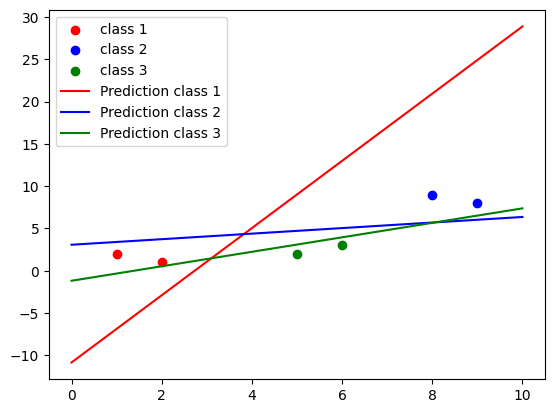

In [18]:
import numpy as np
X = np.array([
    [1, 2],
    [2, 1],
    [8, 9],
    [9, 8],
    [5, 2],
    [6, 3]
])


y = np.array([0, 0, 1, 1, 2, 2])
y_class1_target = (y == 0).astype(int)
y_class2_target = (y == 1).astype(int)
y_class3_target = (y == 2).astype(int)

w1 = logistic_regression_GD(X , y_class1_target)
w2 = logistic_regression_GD(X , y_class2_target)
w3 = logistic_regression_GD(X , y_class3_target)

x_plot = np.linspace(0 , 10 , 200)
x2_1 = -(w1[0] + w1[1] * x_plot) / w1[2]
x2_2 = -(w2[0] + w2[1] * x_plot) / w2[2]
x2_3 = -(w3[0] + w3[1] * x_plot) / w3[2]

plt.scatter(X[y_class1_target == 1 , 0] , X[y_class1_target == 1 , 1] , c = "red" , label = "class 1")
plt.scatter(X[y_class2_target == 1 , 0] , X[y_class2_target == 1 , 1] , c = "blue" , label = "class 2")
plt.scatter(X[y_class3_target == 1 , 0] , X[y_class3_target == 1 , 1] , c = "green" , label = "class 3")
plt.plot(x_plot , x2_1 , c = "red" , label = "Prediction class 1")
plt.plot(x_plot , x2_2 , c = "blue" , label = "Prediction class 2")
plt.plot(x_plot , x2_3 , c = "green" , label = "Prediction class 3")
plt.legend()
plt.show

# Multinomial Logistic Regression — Softmax

## 1. Introduction

Logistic Regression can naturally handle binary classification, where the target contains two classes.

However, many real-world classification problems contain more than two classes.

For example:

$$
y \in {0,1,2}
$$

In this case, we need a method that can calculate the probability of belonging to each class.

One approach is **One-vs-Rest (OvR)**, where a separate binary Logistic Regression model is trained for each class.

Another approach is **Multinomial Logistic Regression**, which uses the **Softmax function** to model all classes simultaneously.

---

## 2. From Binary Logistic Regression to Multiclass Classification

In binary Logistic Regression, we calculate:

$$
z = Xw
$$

and then apply the Sigmoid function:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The result represents the probability of class 1.

For multiclass classification, we need multiple scores.

Suppose we have $K$ classes.

For each class $k$, we calculate:

$$
z_k = Xw_k
$$

Therefore, for one sample we might obtain:

$$
z =
[z_1,z_2,z_3]
$$

These values are called **logits** or class scores.

The logits themselves are not probabilities because they can be any real number.

---

## 3. Softmax Function

The Softmax function converts the class scores into probabilities.

For class $k$:

$$
P(y=k|X)
========

\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

The denominator contains the exponentials of the scores of all classes.

Therefore, the output probabilities satisfy:

$$
0<P(y=k|X)<1
$$

and:

$$
\sum_{k=1}^{K}P(y=k|X)=1
$$

For example, a model might produce:

$$
[0.1,;0.7,;0.2]
$$

This means:

* Class 0 → 10%
* Class 1 → 70%
* Class 2 → 20%

The predicted class is the class with the highest probability:

$$
\hat{y}=\arg\max_k P(y=k|X)
$$

---

## 4. Why Do We Need Softmax?

Sigmoid is designed for binary probability modeling.

With multiple classes, applying an independent Sigmoid to every class would not guarantee that the probabilities add up to one.

Softmax solves this problem by normalizing all class scores together.

For example:

$$
z=[2,1,0]
$$

After applying Softmax, the outputs become approximately:

$$
[0.665,;0.245,;0.090]
$$

and:

$$
0.665+0.245+0.090=1
$$

Therefore, Softmax produces a probability distribution over all classes.

---

## 5. Weight Matrix

In binary Logistic Regression, we had one weight vector:

$$
w
$$

For multiclass Logistic Regression, each class has its own weight vector.

For $K$ classes:

$$
W=
[w_1,w_2,\dots,w_K]
$$

If there are $n$ features, the weight matrix has the form:

$$
W\in\mathbb{R}^{n\times K}
$$

including the bias term if it is represented as an additional feature.

For a sample $x$:

$$
z=xW
$$

This produces one score for every class.

---

## 6. Cross-Entropy Loss

For multiclass Logistic Regression, the Binary Cross-Entropy loss is replaced by **Categorical Cross-Entropy**.

If the true class is $y$ and the predicted probability for that class is $p_y$, the loss for one sample is:

$$
L=-\log(p_y)
$$

For all training samples:

$$
J(W)
====

-\frac{1}{m}
\sum_{i=1}^{m}
\log(P(y_i|x_i))
$$

The model is trained by minimizing this loss.

If the model assigns a high probability to the correct class, the loss is small.

If it assigns a very small probability to the correct class, the loss becomes large.

---

## 7. One-Hot Encoding

For multiclass classification, labels are often represented using One-Hot Encoding.

For three classes:

```text
Class 0 → [1, 0, 0]
Class 1 → [0, 1, 0]
Class 2 → [0, 0, 1]
```

For example:

```text
y = 1
```

becomes:

$$
y=[0,1,0]
$$

This representation makes it possible to compare the true class distribution with the probability distribution predicted by Softmax.

---

## 8. Gradient of Softmax Cross-Entropy

One of the useful properties of Softmax combined with Cross-Entropy is that their gradient has a simple form.

Let:

$$
P = Softmax(XW)
$$

Then the gradient with respect to the weight matrix is:

$$
\nabla W
========

\frac{1}{m}X^T(P-Y)
$$

where:

* $X$ is the feature matrix
* $W$ is the weight matrix
* $P$ is the predicted probability matrix
* $Y$ is the one-hot encoded target matrix
* $m$ is the number of training samples

Gradient Descent updates the weights using:

$$
W:=W-\eta\nabla W
$$

Therefore:

$$
W :=
W-\eta
\frac{1}{m}X^T(P-Y)
$$

---

## 9. Complete Training Process

The complete process can be summarized as:

$$
X
\rightarrow
XW
\rightarrow
Softmax
\rightarrow
P
\rightarrow
P-Y
\rightarrow
\frac{1}{m}X^T(P-Y)
\rightarrow
W-\eta\nabla W
$$

This is the multiclass equivalent of the training process used previously for binary Logistic Regression.

---

## 10. Numerical Stability of Softmax

A direct implementation of Softmax can encounter numerical overflow because of the exponential function.

For example:

$$
e^{1000}
$$

is extremely large.

A common solution is to subtract the maximum logit before applying the exponential:

$$
Softmax(z)_k
============

\frac{e^{z_k-\max(z)}}
{\sum_j e^{z_j-\max(z)}}
$$

This does not change the resulting probabilities, but makes the computation much more numerically stable.

A NumPy implementation can therefore be written as:

```python
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
```

---

## 11. Prediction

After calculating the probability of every class, the predicted class is the class with the highest probability.

For example:

```python
probabilities = np.array([
    [0.1, 0.7, 0.2],
    [0.8, 0.1, 0.1],
    [0.2, 0.3, 0.5]
])
```

The predicted classes are:

```python
predictions = np.argmax(probabilities, axis=1)
```

which produces:

```text
[1, 0, 2]
```

---

## 12. Softmax vs. One-vs-Rest

There are two important approaches for multiclass Logistic Regression.

### One-vs-Rest

A separate binary classifier is trained for each class.

For three classes:

```text
Model 0 → Class 0 vs Rest
Model 1 → Class 1 vs Rest
Model 2 → Class 2 vs Rest
```

The class with the highest score is selected.

### Multinomial Logistic Regression

All classes are modeled simultaneously.

The model produces a score for every class and Softmax converts these scores into a probability distribution.

Therefore:

| Method      | Main Idea                             |
| ----------- | ------------------------------------- |
| One-vs-Rest | Several binary models                 |
| Multinomial | One model with multiple class weights |
| OvR         | Uses binary Logistic Regression       |
| Multinomial | Uses Softmax                          |

---

## 13. Practical Implementation

The goal of this section is to implement Multinomial Logistic Regression from scratch using NumPy.

The implementation will contain:

1. Softmax function
2. Weight matrix initialization
3. Forward pass
4. Cross-Entropy loss
5. Gradient calculation
6. Gradient Descent
7. Probability prediction
8. Class prediction
9. Evaluation
10. Comparison with Scikit-learn

This implementation will demonstrate how the mathematical equations translate directly into code.

---

## 14. Conclusion

Multinomial Logistic Regression extends binary Logistic Regression to problems containing multiple classes.

The main difference is the replacement of the Sigmoid function with Softmax.

The complete process is:

$$
X
\rightarrow
XW
\rightarrow
Softmax
\rightarrow
Class\ Probabilities
\rightarrow
\arg\max
\rightarrow
Predicted\ Class
$$

The combination of Softmax and Cross-Entropy provides a natural way to model mutually exclusive classes.

After implementing Softmax Logistic Regression from scratch, it can be compared with the Scikit-learn implementation to verify the correctness of the implementation and understand how practical machine-learning libraries implement multiclass classification.


In [19]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [20]:
P = np.array([
    [0.1, 0.7, 0.2],
    [0.8, 0.1, 0.1],
    [0.2, 0.2, 0.6],
    [0.1, 0.2, 0.7]
])

Y = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1],
    [0, 0, 1]
])

In [21]:
def cross_entropy2(P, Y):
    return np.mean(-np.mean(Y * np.log(P), axis=1))

In [22]:
print(cross_entropy2(P , Y))

0.12060992191313877


In [23]:
def softmax_regression_GD(x , y , itr = 1000 , eta = 0.1) :
    x = np.c_[np.ones(x.shape[0]) , x]
    w_inital = np.zeros([x.shape[1]  , y.shape[1] ])
    for _ in range(itr) :
        grandiant = x.T @ (softmax(x @ w_inital) - y) / x.shape[0]
        w_inital -= grandiant * eta
    return w_inital

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
X = np.array([
    [1, 2],
    [2, 1],
    [8, 9],
    [9, 8],
    [5, 2],
    [6, 3]
])
Y = np.array([0 , 0 , 1 , 1 , 2 , 2])
Y = Y.reshape(-1 , 1)
ct = ColumnTransformer(transformers = [('encoder' , OneHotEncoder() , [0])]  ,remainder='passthrough')
Y = ct.fit_transform(Y)
Y

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [25]:
X

array([[1, 2],
       [2, 1],
       [8, 9],
       [9, 8],
       [5, 2],
       [6, 3]])

In [26]:
w = softmax_regression_GD(X , Y)
w

array([[ 4.01078517, -2.31848015, -1.69230502],
       [-1.13666276, -0.58605887,  1.72272162],
       [ 0.49651237,  1.39506131, -1.89157368]])

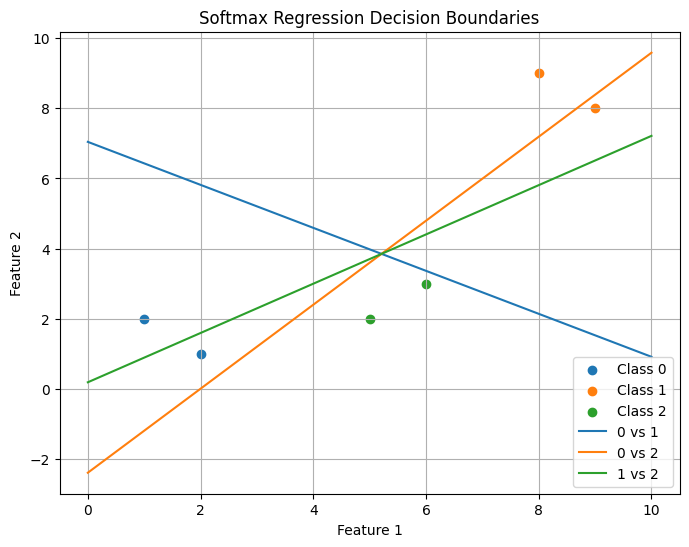

In [27]:
x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)

plt.figure(figsize=(8, 6))

# Data
plt.scatter(X[Y[:, 0] == 1, 0], X[Y[:, 0] == 1, 1], label="Class 0")
plt.scatter(X[Y[:, 1] == 1, 0], X[Y[:, 1] == 1, 1], label="Class 1")
plt.scatter(X[Y[:, 2] == 1, 0], X[Y[:, 2] == 1, 1], label="Class 2")

# Class 0 vs Class 1
x2_01 = -(
    (w[0, 0] - w[0, 1]) +
    (w[1, 0] - w[1, 1]) * x1
) / (w[2, 0] - w[2, 1])

plt.plot(x1, x2_01, label="0 vs 1")

# Class 0 vs Class 2
x2_02 = -(
    (w[0, 0] - w[0, 2]) +
    (w[1, 0] - w[1, 2]) * x1
) / (w[2, 0] - w[2, 2])

plt.plot(x1, x2_02, label="0 vs 2")

# Class 1 vs Class 2
x2_12 = -(
    (w[0, 1] - w[0, 2]) +
    (w[1, 1] - w[1, 2]) * x1
) / (w[2, 1] - w[2, 2])

plt.plot(x1, x2_12, label="1 vs 2")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Softmax Regression Decision Boundaries")
plt.legend()
plt.grid()
plt.show()

In [28]:
X

array([[1, 2],
       [2, 1],
       [8, 9],
       [9, 8],
       [5, 2],
       [6, 3]])

In [29]:
x = np.c_[np.ones(X.shape[0]),X]
z = x @ w
p = softmax(z)
p

array([[9.81212674e-01, 1.83059416e-02, 4.81384629e-04],
       [9.03807772e-01, 1.19067813e-02, 8.42854467e-02],
       [2.10247737e-03, 9.97869582e-01, 2.79406332e-05],
       [2.95272327e-03, 9.89588371e-01, 7.45890562e-03],
       [2.14287016e-02, 3.61677671e-03, 9.74954522e-01],
       [1.34031370e-02, 9.63587976e-03, 9.76960983e-01]])

In [30]:
y_pred = np.argmax(p, axis=1)
y_pred

array([0, 0, 1, 1, 2, 2])

In [31]:
loss = cross_entropy2(p , Y)
loss

np.float64(0.01007647494553912)

In [32]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [33]:
acc = accuracy(y , y_pred)
cm = np.zeros((3, 3), dtype=int)
for true, pred in zip(y, y_pred):
    cm[true, pred] += 1
print(cm)
print("\naccuracy = " , acc)

[[2 0 0]
 [0 2 0]
 [0 0 2]]

accuracy =  1.0


# Tesing our model on a real Dataset

In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_iris()

x = data.data
y = data.target

x_dataframe = pd.DataFrame(x , columns=data.feature_names)

In [35]:
x_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [36]:
x_dataframe.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [37]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state = 42)

In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [39]:
y_train_reshaped = y_train.reshape(-1 , 1)
y_test_reshaped =  y_test.reshape(-1 , 1)
y_train_OH = ct.fit_transform(y_train_reshaped)
y_test_OH = ct.fit_transform(y_test_reshaped)

In [40]:
y_train_OH

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1

In [54]:
x_test_scaled_copy = np.c_[np.ones(x_test_scaled.shape[0]) , x_test_scaled]

In [55]:
w = softmax_regression_GD(x_train_scaled , y_train_OH)

In [56]:
z = x_test_scaled_copy @ w
p = softmax(z)
y_pred = np.argmax(p , axis = 1)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [57]:
cm = confusion_matrix(y_test , y_pred)
acc = accuracy_score(y_test , y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test , y_pred , average = 'macro')
precision = precision_score(y_test , y_pred ,average = 'macro')
print(f"accuracy score = {acc} \nf1 = {f1} \nrecall = {recall} \nprecoision = {precision}")

accuracy score = 1.0 
f1 = 1.0 
recall = 1.0 
precoision = 1.0


In [45]:
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [49]:
x_train_scaled_copy = np.c_[np.ones(x_train_scaled.shape[0]) , x_train_scaled]

In [50]:
z = x_train_scaled_copy @ w
p = softmax(z)
y_pred = np.argmax(p , axis = 1)
y_pred

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

In [51]:
cm = confusion_matrix(y_train , y_pred)
acc = accuracy_score(y_train , y_pred)
f1 = f1_score(y_train, y_pred, average='macro')
recall = recall_score(y_train , y_pred , average = 'macro')
precision = precision_score(y_train , y_pred ,average = 'macro')
print(f"accuracy score = {acc} \nf1 = {f1} \nrecall = {recall} \nprecoision = {precision}")

accuracy score = 0.9666666666666667 
f1 = 0.9666666666666667 
recall = 0.9670627475505524 
precoision = 0.9670627475505524


In [52]:
cm

array([[40,  0,  0],
       [ 0, 38,  3],
       [ 0,  1, 38]])

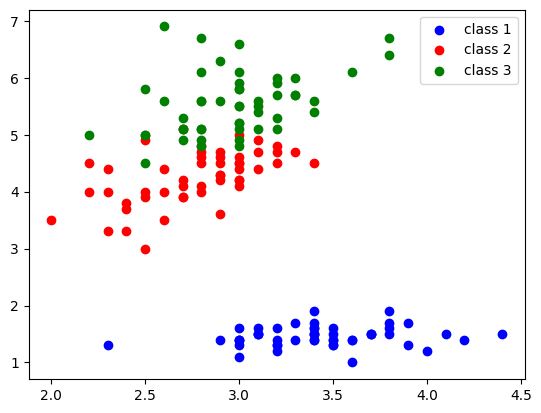

In [48]:
plt.scatter(x[y==0 , 1] , x[y==0 , 2] , c="blue" , label = "class 1")
plt.scatter(x[y==1 , 1] , x[y==1 , 2] , c="red" , label = "class 2")
plt.scatter(x[y==2 , 1] , x[y==2 , 2] , c="green" , label = "class 3")
plt.legend()
plt.show()

## Conclusion

In this section, we extended Logistic Regression from binary classification
to multiclass classification using the Softmax function.

We implemented the complete Softmax Regression algorithm from scratch,
including:

- One-Hot Encoding for multiclass target labels
- Linear scores (logits)
- Softmax probability calculation
- Cross-Entropy Loss
- Gradient calculation
- Gradient Descent optimization
- Prediction using the highest class probability
- Decision boundaries for multiple classes
- Evaluation on training and test data

The model was tested on a multiclass dataset and achieved strong performance,
with an accuracy of approximately 95% on the training data and approximately
95% on the test data.

This demonstrates that the implementation is able to learn the relationship
between the features and multiple target classes effectively.

The main difference between Binary Logistic Regression and Softmax Regression
is the way probabilities are produced:

- Binary Logistic Regression uses the Sigmoid function for two classes.
- Multiclass Logistic Regression uses the Softmax function to produce a
  probability distribution over multiple classes.

The next step is to study K-Nearest Neighbors (KNN), another supervised
learning algorithm with a fundamentally different approach to classification.